# **Distribuição Normal no Mercado Financeiro**

Este código tem como objetivo verificar se os **retornos de um ativo financeiro** seguem uma **distribuição normal**, hipótese comum em modelos financeiros clássicos (como CAPM e Black-Scholes).

## 📊 Metodologia

- Utilizamos uma **janela móvel** para analisar os últimos `n` retornos a cada instante no tempo.
- Em cada janela, os retornos são divididos em **intervalos (bins)** e:
  - Calculamos a **frequência observada** de retornos em cada bin.
  - Estimamos a **frequência esperada**, assumindo que os retornos seguem uma distribuição **normal** com média e desvio padrão amostrais.
- Aplicamos o **teste do qui-quadrado de aderência**, que verifica se a distribuição observada difere significativamente da distribuição esperada.

## 📌 Sobre o teste qui-quadrado

O **teste qui-quadrado de aderência** é utilizado para avaliar se os dados observados seguem uma distribuição teórica especificada.  
Neste caso, testamos:

- **H₀ (hipótese nula):** os retornos seguem uma distribuição normal.
- **H₁ (hipótese alternativa):** os retornos **não** seguem uma distribuição normal.

Se a estatística do teste ultrapassar o **valor crítico** (ou se o **p-valor < α**, por exemplo 0.05), rejeitamos a hipótese de normalidade.

---

💡 Essa análise é especialmente útil para validar suposições estatísticas antes de aplicar modelos financeiros ou testes baseados na normalidade dos dados.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import requests
from scipy.stats import norm
from scipy.stats import chi2

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter # formatar a data no eixo x 
import matplotlib.gridspec as gridspec # subplots com tamanhos diferentes
plt.style.use('seaborn-v0_8-darkgrid') # mudar o estilo do matplotlib

import yfinance as yf
from curl_cffi import requests

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Baixando os dados
TICKER = 'BTC-USD'  # Exemplo de ticker
start_date = '2024-01-01'
end_date = '2026-01-01'


# Create a session that impersonates a browser
session = requests.Session(impersonate="safari15_5")  # Or "chrome120", etc.

try:
    ticker_obj = yf.Ticker(TICKER, session=session)
    ticker_data = ticker_obj.history(start= start_date, end= end_date, interval='1d')
    df = pd.DataFrame(ticker_data)
    df['Returns'] = df['Close'].pct_change()  # Calculate returns
except Exception as e:
    print(f"Error downloading data: {e}")
    
   
# Excluindo valores NaN
df = df.dropna()


# Exibindo as primeiras linhas do DataFrame
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns
Date,,,,,,,,
2024-01-02 00:00:00+00:00,44187.140625,45899.707031,44176.949219,44957.968750,39335274536,0.0,0.0,0.017901
2024-01-03 00:00:00+00:00,44961.601562,45503.242188,40813.535156,42848.175781,46342323118,0.0,0.0,-0.046928
2024-01-04 00:00:00+00:00,42855.816406,44770.023438,42675.175781,44179.921875,30448091210,0.0,0.0,0.031081
2024-01-05 00:00:00+00:00,44192.980469,44353.285156,42784.718750,44162.691406,32336029347,0.0,0.0,-0.000390
2024-01-06 00:00:00+00:00,44178.953125,44227.632812,43475.156250,43989.195312,16092503468,0.0,0.0,-0.003929


# Distribuição dos retornos 

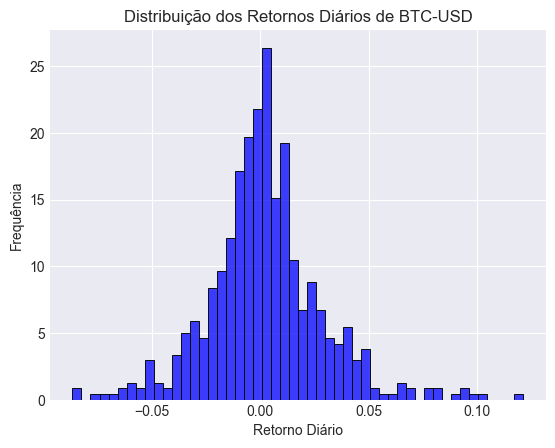

In [3]:
# Distribuição dos retornos

sns.histplot(df['Returns'].dropna(), bins=50, kde=False, color='blue', stat='density')
plt.title(f'Distribuição dos Retornos Diários de {TICKER}')
plt.xlabel('Retorno Diário')
plt.ylabel('Frequência')
plt.show();

# **Teste de Aderência**

### Ho : Os dados são normalmente distribuidos 
### Ha : Os dados não são normalmente distribuidos

In [4]:
# Parâmetros
n = 100
ALPHA = 0.01  # Nível de significância
num_bins = 5 # Número de bins para o histograma

In [5]:
# Inicializar listas para armazenar resultados
chi2_stats = []
chi2_crits = []
reject_H0 = []

# Verificar se o DataFrame tem dados suficientes
if len(df) < n + 1:
    raise ValueError(f"O DataFrame tem {len(df)} linhas, mas são necessárias pelo menos {n + 1} linhas (n={n} retornos anteriores + 1 valor presente).")

# Iterar sobre as janelas, começando do índice n
for i in range(n, len(df)):
    # Obter os n retornos anteriores
    past_returns = df['Returns'].iloc[i - n:i]
    # Obter o valor presente
    current_return = df['Returns'].iloc[i]
    
    # Verificar se há NaN nos retornos anteriores ou no valor presente
    if past_returns.isna().any() or np.isnan(current_return):
        chi2_stats.append(np.nan)
        chi2_crits.append(np.nan)
        reject_H0.append(np.nan)
        continue
    
    # Calcular média e desvio padrão dos n retornos anteriores
    mean = past_returns.mean()
    std_dev = past_returns.std(ddof=1)  # Usar ddof=1 para desvio padrão amostral
    
    # Verificar se o desvio padrão é válido
    if std_dev == 0 or np.isnan(std_dev) or np.isnan(mean):
        chi2_stats.append(np.nan)
        chi2_crits.append(np.nan)
        reject_H0.append(np.nan)
        continue
    
    # Criar histograma dos retornos anteriores
    observed_freq, bin_edges = np.histogram(past_returns, bins=num_bins)
    
    # Calcular frequências esperadas sob a distribuição normal
    cdf_values = norm.cdf(bin_edges, loc=mean, scale=std_dev)
    probabilities = np.diff(cdf_values)  # Probabilidade de cada bin
    expected_freq = n * probabilities  # Frequência esperada para cada bin
    
    # Evitar divisão por zero nas frequências esperadas
    expected_freq = np.where(expected_freq == 0, 1e-10, expected_freq)
    
    # Determinar em qual bin o valor presente cai
    bin_index = np.digitize(current_return, bin_edges) - 1
    if bin_index < 0 or bin_index >= len(observed_freq):
        chi2_stats.append(np.nan)
        chi2_crits.append(np.nan)
        reject_H0.append(np.nan)
        continue
    
    # Ajustar a frequência observada para o valor presente
    observed_freq_current = np.zeros_like(observed_freq)
    observed_freq_current[bin_index] = 1  # O valor presente contribui com 1 para o bin correspondente
    
    # Calcular a estatística qui-quadrado
    chi2_statistic = np.sum((observed_freq_current - expected_freq / n)**2 / (expected_freq / n))
    
    # Graus de liberdade: número de bins - 1 - 2 (média e desvio padrão estimados)
    df_qui2 = num_bins - 3
    
    # Calcular o valor crítico
    chi2_crit = chi2.ppf(1 - ALPHA, df_qui2) if df_qui2 > 0 else np.nan
    
    # Armazenar resultados
    chi2_stats.append(chi2_statistic)
    chi2_crits.append(chi2_crit)
    reject_H0.append(chi2_statistic > chi2_crit if df_qui2 > 0 else np.nan)

# Adicionar resultados ao DataFrame, alinhando com os índices correspondentes
# Inicializar as colunas com NaN
df['chi2_stat'] = np.nan
df['chi2_crit'] = np.nan
df['reject_H0'] = np.nan

# Atribuir os resultados às linhas corretas (a partir do índice n)
df.iloc[n:, df.columns.get_loc('chi2_stat')] = chi2_stats
df.iloc[n:, df.columns.get_loc('chi2_crit')] = chi2_crits
df.iloc[n:, df.columns.get_loc('reject_H0')] = reject_H0

# Resumo dos resultados
print(f"Número de testes realizados: {len(chi2_stats)}")
print(f"Número de vezes que H0 (normalidade do valor presente) foi rejeitada: {np.sum([x for x in reject_H0 if not np.isnan(x)])}")

Número de testes realizados: 473
Número de vezes que H0 (normalidade do valor presente) foi rejeitada: 28


# Gráfico 

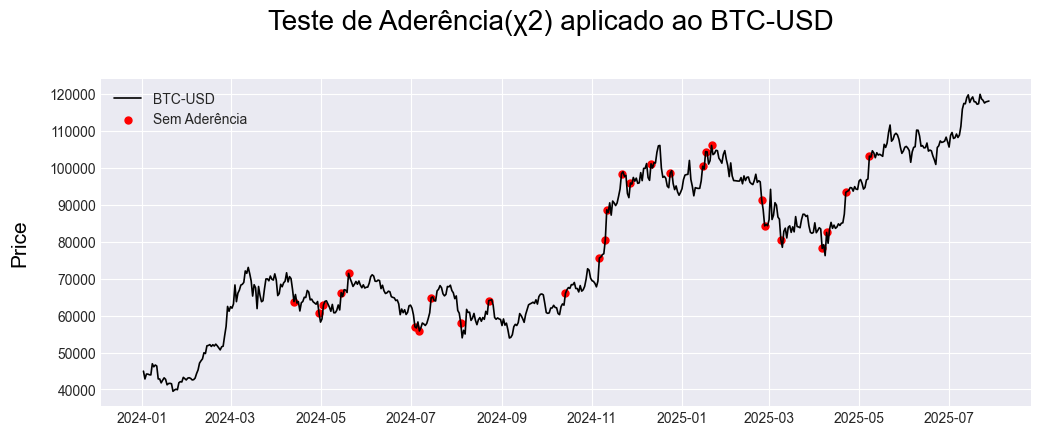

In [6]:
fig =  plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1],  hspace=0.2) # define a proporção de altura dos subplots

ax0 = fig.add_subplot(gs[0]) # primeiro subplot
axs = [ax0] # lista de eixos para facilitar o acesso

# Plotando o gráfico de preços e o valor z
axs[0].plot(df.index, df['Close'], color='black', label= TICKER, linewidth=1.2)

# plot para os pontos onde a hipótese nula é rejeitada
axs[0].scatter(df.index, np.where(df['reject_H0'] == 1, df['Close'], np.nan),
            color="red", label='Sem Aderência', s=25, marker = 'o')   


axs[0].set_ylabel('Price', fontsize=15, color='black', labelpad=15)
axs[0].legend()
axs[0].grid(True)  

# Fixando as legendas no canto superior esquerdo
axs[0].legend(loc='upper left')


# Layout 
fig.tight_layout()
fig.suptitle(f'Teste de Aderência(χ2) aplicado ao {TICKER}', fontsize=20, color='black')
fig.show()